# 04b — Locomotor resilience dynamics (Antoine Dufourneau method, adapted)

Quantifies the **temporal dynamics** of recovery after the sand perturbation:

- **Reference trajectory** : pre-perturbation phase-space, Fourier-smoothed (order 8) over 360° phase angles.
- **Distance signal** `XR_distances` : Euclidean distance between actual phase-space trajectory and reference.
- **Stability zones** T1/T2/T3 (1σ/2σ/3σ ellipsoids), scaled by 97.5% quantile of pre-perturbation.
- **Resilience metrics**:
    - **T_L** lag time : pert_entry → first significant deviation
    - **T_P** peak time : lag → peak (searched on [pert_entry, pert_exit + 5s])
    - **T_S** recovery time : pert_exit → stable return (post-perturbation)
    - **P** persistent : mean post-recovery vs pre-perturbation (15, 30, 45, 60 s)
    - **pct_T1/T2/T3** : stability zone percentages during pre-perturbation

## Inputs / Outputs
- Input  : `data/processed/*.npz`, `outputs/tables/03_tde_per_participant.csv`
- Output : `outputs/tables/04b_resilience_dynamics.csv`, `outputs/figures/04b_*.png`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from resilience import config, participants, paths
from resilience.io import writer
from resilience.analysis import resilience_dynamics as rd
from resilience.analysis import resilience_workflow as rw

OUT_TABLES = Path(paths.OUTPUTS_DIR) / 'tables'
OUT_FIGURES = Path(paths.OUTPUTS_DIR) / 'figures'
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load TDE params and perturbation timestamps

In [2]:
tde_params = rw.load_tde_params()
trials = rw.load_all_trials(verbose=True)
print(f'TDE params: {len(tde_params)} participants')
print(f'Trials with perturbation detected: {len(trials)}')

C:\Users\etulyon1\Documents\PYTHON-R-GIT\1_Projects\resilience-locomotor-aging-RAS_v2\src\resilience\analysis\resilience_workflow.py:125: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)


  ✅ 46 trials loaded
TDE params: 16 participants
Trials with perturbation detected: 46


## 2. Process one trial (demo + sanity check)

In [3]:
def process_one_trial(code, cond, data, tau, dim, plot=False):
    """Run the full resilience dynamics pipeline on one trial."""
    fs = data['fs']
    signal_z = data['signal_z']
    pert_entry_s = data['pert_entry']
    pert_exit_s  = data['pert_exit']
    pert_entry_idx = int(pert_entry_s * fs)
    pert_exit_idx  = int(pert_exit_s  * fs)

    # Detrend
    sig_d, drift_amp, drift_applied = rd.detrend_drift(signal_z)

    # Phase-space embedding
    xr = rd.phase_space_reconstruction(sig_d, tau=tau, dim=dim)

    # XR is shorter than sig_d by pad = (dim-1)*tau samples
    pad = (dim - 1) * tau
    pert_entry_xr = max(0, min(pert_entry_idx - pad, len(xr) - 1))
    pert_exit_xr  = max(0, min(pert_exit_idx  - pad, len(xr) - 1))

    # Pre-perturbation slice for reference trajectory
    pre_end = max(1, pert_entry_xr)
    xr_pre = xr[:pre_end, :3]
    if len(xr_pre) < 100:
        return None

    # Reference trajectory
    ref = rd.compute_reference_trajectory(xr_pre)

    # Local std per phase angle
    std_x, std_y, std_z = rd.compute_local_std(
        ref['xr_pre_sorted'], ref['phase_pre'], ref['ref_traj']
    )

    # XR distances
    xr_distances, xr_phase = rd.compute_xr_distances(xr, ref)

    # Stability zones
    stab = rd.compute_stability_zones(
        xr_distances, xr_phase, std_x, std_y, std_z,
        pert_entry_idx=pert_entry_xr,
        fs=fs,
    )

    # Heel strikes in XR index space
    heel_strikes = rd.detect_heel_strikes(sig_d)
    heel_strikes_xr = heel_strikes - pad
    heel_strikes_xr = heel_strikes_xr[(heel_strikes_xr >= 0) & (heel_strikes_xr < len(xr_distances))]

    metrics = rd.compute_resilience_metrics(
        xr_distances, stab,
        pert_entry_idx=pert_entry_xr,
        pert_exit_idx=pert_exit_xr,
        heel_strikes=heel_strikes_xr,
        fs=fs,
    )

    persistent = rd.compute_persistent_difference(
        xr_distances, pert_entry_xr, metrics['recovery_idx'], fs=fs
    )

    row = {
        'participant':    code,
        'condition':      cond,
        'tau':            tau,
        'dim':            dim,
        'drift_amp_mm':   round(drift_amp, 3),
        'drift_applied':  drift_applied,
        'pert_entry_s':   round(pert_entry_s, 2),
        'pert_exit_s':    round(pert_exit_s, 2),
        'lag_time_s':       np.round(metrics['lag_time_s'], 3),
        'peak_time_s':      np.round(metrics['peak_time_s'], 3),
        'recovery_time_s':  np.round(metrics['recovery_time_s'], 3),
        'peak_distance_mm': np.round(metrics['peak_distance_mm'], 2),
        'n_steps_recovery': metrics['n_steps_recovery'],
        'pct_T1':  round(stab['pct_T1'],  1),
        'pct_T2':  round(stab['pct_T2'],  1),
        'pct_T3':  round(stab['pct_T3'],  1),
        'pct_out': round(stab['pct_out'], 1),
        'resolution4':   round(stab['resolution4'], 3),
        'baseline_mean': round(persistent['baseline_mean'], 2),
    }
    for w in config.RESILIENCE_PERSISTENT_WINDOWS_S:
        pd_val  = persistent['persistent_diff'][w]
        pct_val = persistent['persistent_diff_pct'][w]
        row[f'persistent_diff_{int(w)}s'] = round(pd_val,  3) if not np.isnan(pd_val)  else np.nan
        row[f'persistent_pct_{int(w)}s']  = round(pct_val, 2) if not np.isnan(pct_val) else np.nan

    if plot:
        fig, ax = plt.subplots(figsize=(14, 4))
        t_axis = (np.arange(len(xr_distances)) + pad) / fs
        ax.plot(t_axis, xr_distances, color='#677C8E', lw=1.0, alpha=0.7)
        ax.plot(t_axis, stab['stability_01'],      color='#E54ED1', lw=1.2, label='T1 very stable')
        ax.plot(t_axis, stab['stability_01_02'],   color='#EDB314', lw=1.2, label='T2 stable')
        ax.plot(t_axis, stab['instability_02_03'], color='#BFD834', lw=1.2, label='T3 unstable')
        ax.plot(t_axis, stab['instability_03'],    color='#000761', lw=1.2, label='>T3 very unstable')
        ax.axvline(pert_entry_s, color='gold',       lw=2, ls='--', label='pert entry')
        ax.axvline(pert_exit_s,  color='darkorange', lw=2, ls='--', label='pert exit')
        if not np.isnan(metrics['lag_idx']):
            t_lag = (metrics['lag_idx'] + pad) / fs
            ax.axvline(t_lag, color='magenta', lw=1.5, ls=':', label=f'lag (+{metrics["lag_time_s"]:.2f}s)')
        if not np.isnan(metrics['peak_idx']):
            t_peak = (metrics['peak_idx'] + pad) / fs
            ax.axvline(t_peak, color='red', lw=1.5, ls=':', label=f'peak (+{metrics["peak_time_s"]:.2f}s)')
        if not np.isnan(metrics['recovery_idx']):
            t_rec = (metrics['recovery_idx'] + pad) / fs
            ax.axvline(t_rec, color='green', lw=1.5, ls=':', label=f'recovery (+{metrics["recovery_time_s"]:.2f}s)')
        ax.set_xlim(max(0, pert_entry_s - 15), min(t_axis[-1], pert_exit_s + 45))
        ax.set_xlabel('time (s, post-crop)'); ax.set_ylabel('XR distance (mm)')
        ax.set_title(f'{code} / {cond} \u2014 resilience dynamics')
        ax.legend(loc='upper right', fontsize=8, ncol=2)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return row

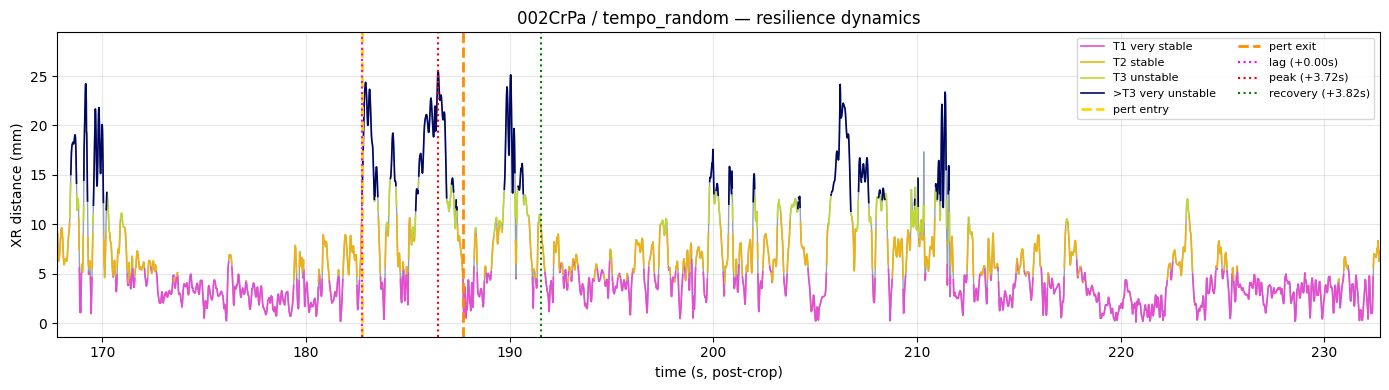

{'participant': '002CrPa',
 'condition': 'tempo_random',
 'tau': 17,
 'dim': 4,
 'drift_amp_mm': 0.533,
 'drift_applied': True,
 'pert_entry_s': 182.78,
 'pert_exit_s': 187.73,
 'lag_time_s': np.float64(0.0),
 'peak_time_s': np.float64(3.72),
 'recovery_time_s': np.float64(3.82),
 'peak_distance_mm': np.float64(25.54),
 'n_steps_recovery': 9,
 'pct_T1': np.float64(67.8),
 'pct_T2': np.float64(26.5),
 'pct_T3': np.float64(3.1),
 'pct_out': np.float64(2.5),
 'resolution4': 1.392,
 'baseline_mean': 3.81,
 'persistent_diff_15s': 2.961,
 'persistent_pct_15s': 77.72,
 'persistent_diff_30s': 2.623,
 'persistent_pct_30s': 68.84,
 'persistent_diff_45s': 2.017,
 'persistent_pct_45s': 52.94,
 'persistent_diff_60s': 1.651,
 'persistent_pct_60s': 43.34}

In [27]:
demo_code, demo_cond = '002CrPa', 'tempo_random'
tau, dim = tde_params[demo_code]
demo_row = process_one_trial(demo_code, demo_cond, trials[(demo_code, demo_cond)], tau, dim, plot=True)
demo_row

## 3. Batch on all trials

In [5]:
rows = []
for (code, cond), data in trials.items():
    if code not in tde_params:
        print(f'  ⚠️  no TDE params for {code}, skip')
        continue
    tau, dim = tde_params[code]
    try:
        row = process_one_trial(code, cond, data, tau, dim, plot=False)
        if row is not None:
            rows.append(row)
    except Exception as e:
        print(f'  ⚠️  {code}/{cond}: {type(e).__name__}: {e}')

df = pd.DataFrame(rows)
print(f'\n✅ {len(df)} trials processed')
df.head()


✅ 46 trials processed


,participant,condition,tau,dim,drift_amp_mm,drift_applied,pert_entry_s,pert_exit_s,lag_time_s,peak_time_s,...,resolution4,baseline_mean,persistent_diff_15s,persistent_pct_15s,persistent_diff_30s,persistent_pct_30s,persistent_diff_45s,persistent_pct_45s,persistent_diff_60s,persistent_pct_60s
0,001CrMa,silence,17,4,0.020,True,198.50,203.35,0.00,0.02,...,1.709,6.98,-1.773,-25.40,-0.676,-9.68,-0.538,-7.70,-0.409,-5.85
1,001CrMa,tempo_random,17,4,0.096,True,188.61,192.96,0.40,0.48,...,1.499,8.19,-3.072,-37.50,-2.140,-26.12,-1.116,-13.62,-1.291,-15.75
2,001CrMa,beatmove_adaptatif,17,4,0.049,True,193.36,197.54,0.00,0.90,...,1.620,9.13,-1.370,-15.01,-0.614,-6.73,-1.043,-11.43,-1.063,-11.65
3,002CrPa,silence,17,4,0.321,True,217.43,222.38,0.00,1.31,...,1.449,8.35,-3.409,-40.84,-3.334,-39.94,-2.967,-35.55,-3.064,-36.71
4,002CrPa,beatmove_adaptatif,17,4,0.150,True,123.60,128.53,0.02,7.68,...,1.508,9.05,-3.828,-42.30,-2.602,-28.75,-2.389,-26.41,-2.653,-29.31


## 4. Descriptive statistics

In [8]:
key_metrics = ['lag_time_s', 'peak_time_s', 'recovery_time_s',
                'peak_distance_mm', 'n_steps_recovery',
                'pct_T1', 'pct_T2', 'pct_T3',
                'persistent_diff_15s', 'persistent_diff_30s',
                'persistent_diff_45s', 'persistent_diff_60s']

for m in key_metrics:
    print(f'\n--- {m} ---')
    print(df.groupby('condition')[m].describe()[['count', 'mean', '50%', 'std']].round(3))


--- lag_time_s ---
                    count   mean   50%    std
condition                                    
beatmove_adaptatif   15.0  1.366  0.31  2.479
silence              15.0  1.493  0.29  2.377
tempo_random         16.0  0.361  0.00  0.566

--- peak_time_s ---
                    count   mean    50%    std
condition                                     
beatmove_adaptatif   14.0  2.696  1.525  2.819
silence              15.0  1.197  0.750  1.305
tempo_random         16.0  2.564  2.880  1.993

--- recovery_time_s ---
                    count   mean   50%     std
condition                                     
beatmove_adaptatif   14.0  3.116  2.18   3.092
silence              14.0  5.759  2.41  11.985
tempo_random         15.0  2.618  2.29   2.929

--- peak_distance_mm ---
                    count    mean    50%     std
condition                                       
beatmove_adaptatif   14.0  34.376  31.12  10.716
silence              15.0  33.925  30.89  12.137
tempo_random

## 5. Boxplots by condition

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_15948\3295467888.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, patch_artist=True, labels=['sil', 'tem', 'bea'])
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_15948\3295467888.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, patch_artist=True, labels=['sil', 'tem', 'bea'])
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_15948\3295467888.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, patch_artist=True, labels=['sil', 'tem', 'bea'])
C:\Users\etulyon1\AppData\Local\Temp\ipykernel

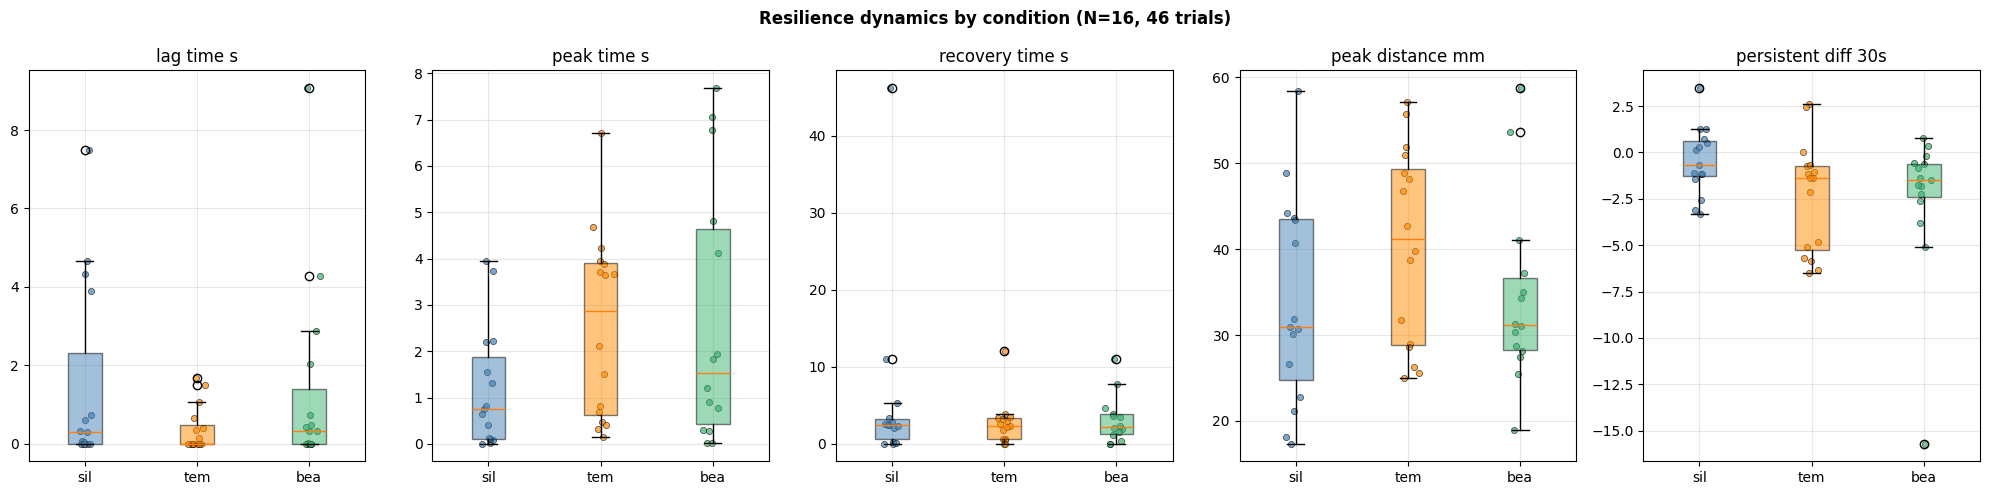

In [9]:
plot_metrics = ['lag_time_s', 'peak_time_s', 'recovery_time_s',
                'peak_distance_mm', 'persistent_diff_30s']
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4*len(plot_metrics), 5))

cond_order = ['silence', 'tempo_random', 'beatmove_adaptatif']
cond_colors = {'silence': 'steelblue', 'tempo_random': 'darkorange', 'beatmove_adaptatif': 'mediumseagreen'}

for ax, m in zip(axes, plot_metrics):
    data_plot = [df[df['condition'] == c][m].dropna().values for c in cond_order]
    bp = ax.boxplot(data_plot, patch_artist=True, labels=['sil', 'tem', 'bea'])
    for patch, c in zip(bp['boxes'], cond_order):
        patch.set_facecolor(cond_colors[c])
        patch.set_alpha(0.5)
    for i, vals in enumerate(data_plot):
        if len(vals) > 0:
            x = np.random.normal(i + 1, 0.04, size=len(vals))
            ax.scatter(x, vals, color=cond_colors[cond_order[i]], s=20, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(m.replace('_', ' '))
    ax.grid(alpha=0.3)

plt.suptitle(f'Resilience dynamics by condition (N={df["participant"].nunique()}, {len(df)} trials)',
              fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_FIGURES / '04b_dynamics_by_condition.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Export

In [10]:
out_csv = OUT_TABLES / '04b_resilience_dynamics.csv'
df.to_csv(out_csv, index=False)
print(f'✅ Exported: {out_csv}')
print(f'   {len(df)} trials, {df["participant"].nunique()} participants')

✅ Exported: C:\Users\etulyon1\Documents\PYTHON-R-GIT\1_Projects\resilience-locomotor-aging-RAS_v2\outputs\tables\04b_resilience_dynamics.csv
   46 trials, 16 participants
